# 01 – Exploratory Data Analysis
Análisis exploratorio del dataset de precios de automóviles.

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
%matplotlib inline

df = pd.read_csv('../data/raw/data.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (11914, 16)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   str    
 10  Vehicle Size       11914 non-null  str    
 11  Vehicle Style      11914 non-null  str    
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

In [3]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [4]:
df.isnull().sum().sort_values(ascending=False)

Market Category      3742
Engine HP              69
Engine Cylinders       30
Number of Doors         6
Engine Fuel Type        3
Model                   0
Year                    0
Make                    0
Driven_Wheels           0
Transmission Type       0
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

## Distribución de MSRP (target)

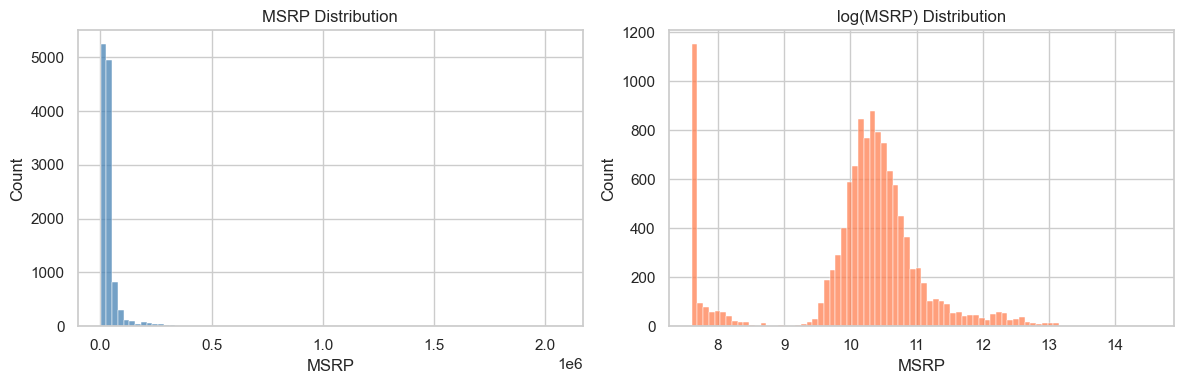

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["MSRP"], bins=80, ax=ax1, color="steelblue")
ax1.set_title("MSRP Distribution")
sns.histplot(np.log1p(df["MSRP"]), bins=80, ax=ax2, color="coral")
ax2.set_title("log(MSRP) Distribution")
plt.tight_layout()

## Variables numéricas vs MSRP

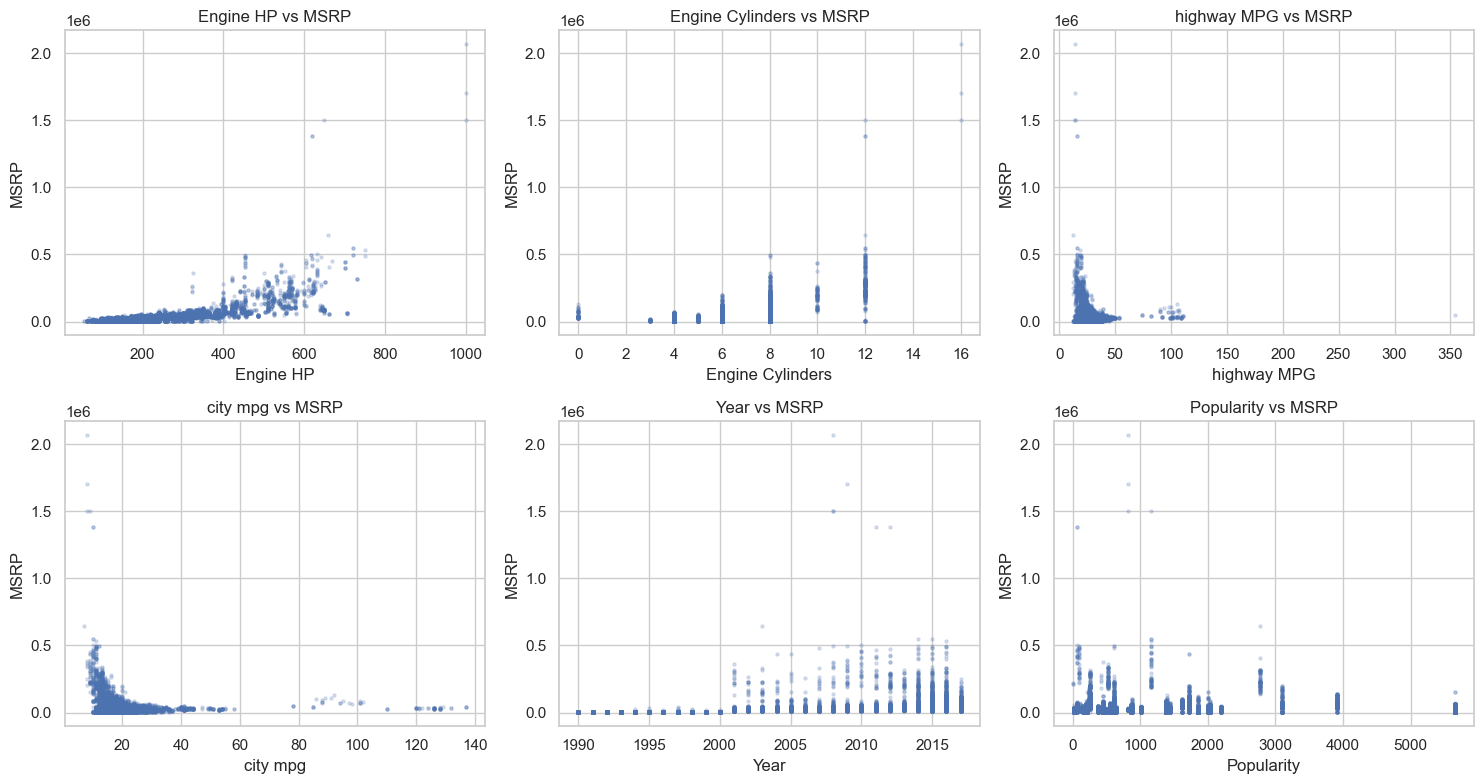

In [6]:
num_cols = ["Engine HP", "Engine Cylinders", "highway MPG", "city mpg", "Year", "Popularity"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols):
    ax.scatter(df[col], df["MSRP"], alpha=0.2, s=5)
    ax.set_xlabel(col); ax.set_ylabel("MSRP")
    ax.set_title(f"{col} vs MSRP")
plt.tight_layout()

## Mapa de correlaciones

Text(0.5, 1.0, 'Correlation Matrix')

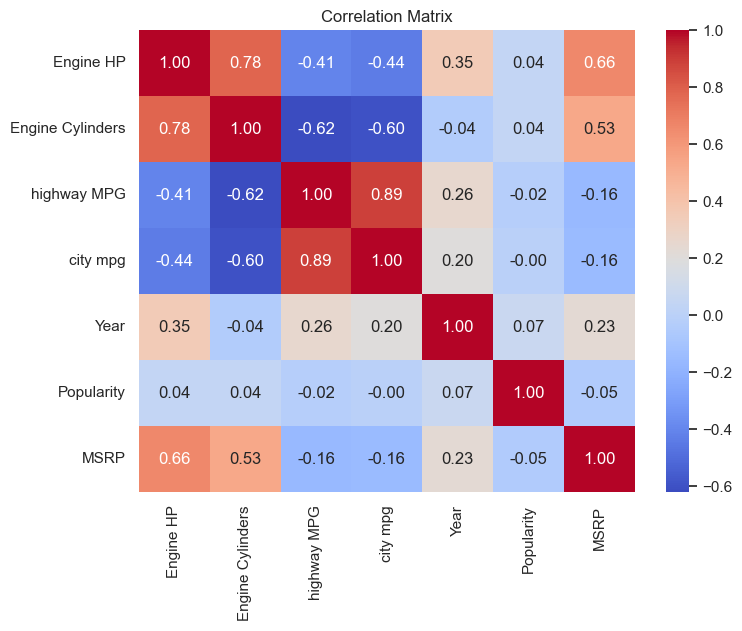

In [7]:
corr = df[num_cols + ["MSRP"]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Matrix")

## Variables categóricas

In [8]:
cat_cols = ["Make", "Vehicle Size", "Vehicle Style", "Transmission Type", "Driven_Wheels"]
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(5))
    print()

Make: 48 unique values
Make
Chevrolet     1123
Ford           881
Volkswagen     809
Toyota         746
Dodge          626
Name: count, dtype: int64

Vehicle Size: 3 unique values
Vehicle Size
Compact    4764
Midsize    4373
Large      2777
Name: count, dtype: int64

Vehicle Style: 16 unique values
Vehicle Style
Sedan            3048
4dr SUV          2488
Coupe            1211
Convertible       793
4dr Hatchback     702
Name: count, dtype: int64

Transmission Type: 5 unique values
Transmission Type
AUTOMATIC           8266
MANUAL              2935
AUTOMATED_MANUAL     626
DIRECT_DRIVE          68
UNKNOWN               19
Name: count, dtype: int64

Driven_Wheels: 4 unique values
Driven_Wheels
front wheel drive    4787
rear wheel drive     3371
all wheel drive      2353
four wheel drive     1403
Name: count, dtype: int64



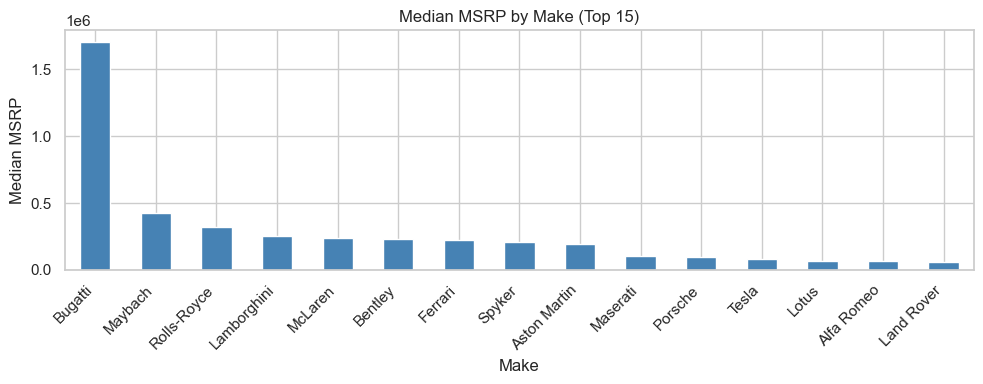

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
top_makes = df.groupby("Make")["MSRP"].median().sort_values(ascending=False).head(15)
top_makes.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Median MSRP by Make (Top 15)")
ax.set_ylabel("Median MSRP")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

---
## Análisis No Supervisado: PCA + Clustering

Antes del modelado supervisado, exploramos la **estructura latente** del dataset usando técnicas no supervisadas.

**¿Por qué no supervisado primero?**
- Detecta agrupaciones naturales en los datos
- PCA revela qué combinaciones de features capturan más varianza
- Los clusters pueden revelar segmentos de mercado no evidentes


In [10]:
import sys; sys.path.insert(0, "..")
import pandas as pd
from src.unsupervised import run_unsupervised

X_train = pd.read_csv("../data/processed/X_train.csv")

# Ejecuta PCA + KMeans + DBSCAN + Agglomerative
# Guarda todos los gráficos en results/plots/
results = run_unsupervised(X_train)

print(f"\n>> PCA: componentes seleccionados automáticamente para retener 95% varianza")
print(f">> k óptimo (Silhouette): {results['best_k']}")



  UNSUPERVISED LEARNING
  Guardado: Saved: results\plots/pca_variance.png
>> PCA: 92 features → 32 components (95.1% variance retained)


c:\Users\isaia\Downloads\ProyectoDataset_FINAL (1)\ProyectoDataset_v2\notebooks\..\src\unsupervised.py:120: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


  Guardado: Saved: results\plots/pca_2d_projection_(no_labels).png
>> Optimal k by silhouette: 2  (silhouette=0.2038)
  Guardado: Saved: results\plots/kmeans_elbow_silhouette.png
>> KMeans (k=2)  |  Silhouette=0.2038  |  Davies-Bouldin=1.7496
>> DBSCAN (eps=1.5, min_samples=10)  |  Clusters=81  |  Noise points=853 (8.9%)
   Silhouette (excl. noise): -0.1288
>> Agglomerative (k=2, Ward)  |  Silhouette=0.1454  |  Davies-Bouldin=2.1920
  Guardado: Saved: results\plots/pca_2d_–_kmeans_clusters.png
  Guardado: Saved: results\plots/pca_2d_–_dbscan_clusters.png
  Guardado: Saved: results\plots/pca_2d_–_agglomerative_clusters.png
  Guardado: Saved: results\plots/dendrogram.png

>> Clustering Summary:
    Algorithm  n_clusters  Silhouette ↑  Davies-Bouldin ↓
       KMeans           2        0.2038            1.7496
       DBSCAN          81       -0.1288            1.2098
Agglomerative           2        0.1454            2.1920

>> PCA: componentes seleccionados automáticamente para retener 95

### Resultados del Clustering



**Interpretación:** Los valores bajos de Silhouette indican que el dataset de precios de autos **no tiene clusters bien separados en el espacio PCA**. 
Esto es esperable: el precio es un continuo influenciado por múltiples factores graduales. 
DBSCAN detecta muchos micro-clusters, sugiriendo que la distribución es multimodal y difusa. 
El dendrograma (agrupamiento jerárquico) confirma que la separación más natural es entre **vehículos económicos y de lujo** (k=2).

*(Ver gráficos: results/plots/pca_variance.png, kmeans_elbow_silhouette.png, pca_2d_–_kmeans_clusters.png, dendrogram.png)*


In [11]:
# Mostrar tabla de métricas de clustering
import pandas as pd
df_clustering = pd.read_csv("../results/metrics/clustering_metrics.csv")
print("Tabla comparativa de algoritmos de clustering:")
print(df_clustering.to_string(index=False))

# Mostrar gráficos de clusters
from PIL import Image
import matplotlib.pyplot as plt
import os

plots = [
    ("../results/plots/pca_variance.png", "PCA: Varianza Explicada"),
    ("../results/plots/kmeans_elbow_silhouette.png", "Método del Codo + Silueta"),
    ("../results/plots/pca_2d_–_kmeans_clusters.png", "KMeans Clusters (PCA 2D)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (path, title) in zip(axes, plots):
    if os.path.exists(path):
        img = Image.open(path)
        ax.imshow(img); ax.axis("off"); ax.set_title(title, fontweight="bold")
plt.tight_layout()
plt.show()


Tabla comparativa de algoritmos de clustering:
    Algorithm  n_clusters  Silhouette ↑  Davies-Bouldin ↓
       KMeans           2        0.2038            1.7496
       DBSCAN          81       -0.1288            1.2098
Agglomerative           2        0.1454            2.1920


C:\Users\isaia\AppData\Local\Temp\ipykernel_8340\342662587.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
